## Nearest Neighbor Heuristic in Classic Vehicle Routing Problem (CVRP)

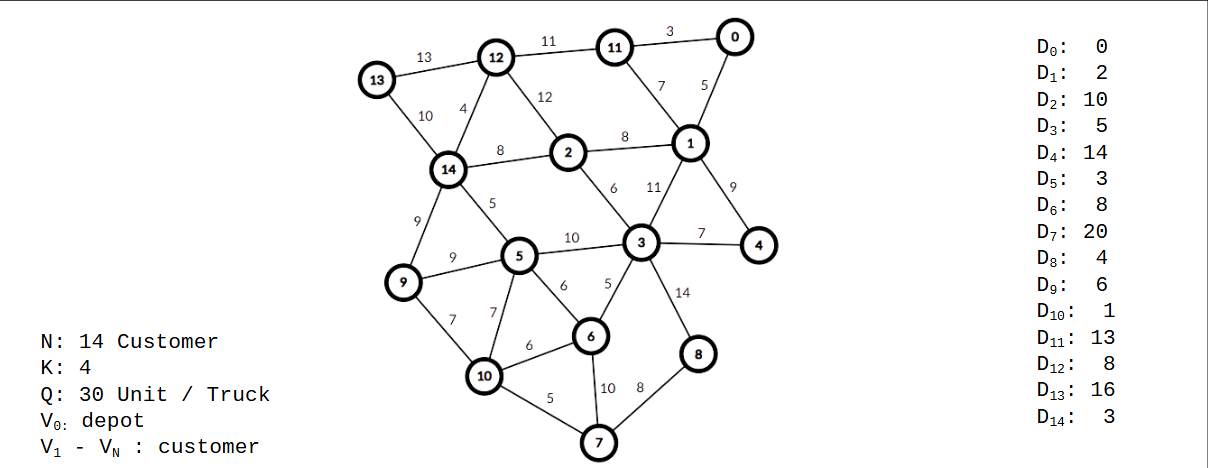

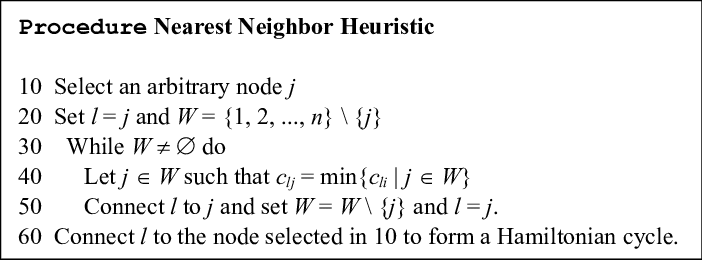
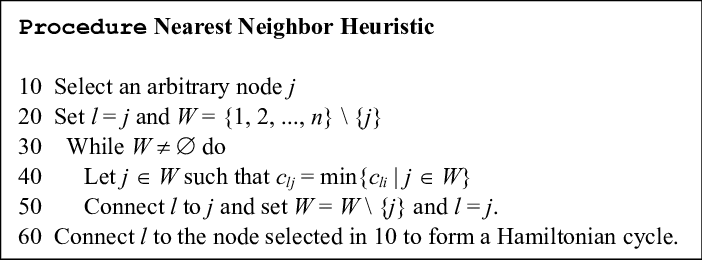

In [21]:
import numpy as np
import math
import networkx as nx
import matplotlib.pyplot as plt
from PIL import Image, ImageOps, ImageFilter
import random
import pandas as pd

n = 15
INF = 10**6

adj = [[INF]*n for _ in range(n)]
for i in range(n):
    adj[i][i] = 0

edges = [
    (0,11,3), (0,1,5), (1,11,7),
    (1,2,8), (1,3,11), (1,4,9),
    (2,12,12), (2,14,8), (2,3,6),
    (3,5,10), (3,6,5), (3,8,14),
    (3,4,7), (5,14,5), (5,9,9),
    (5,6,6), (6,10,6),
    (6,7,10), (6,8,8), (7,10,5),
    (7,8,8), (8,3,14), (8,6,8),
    (8,7,8), (9,14,9), (9,5,9),
    (9,10,7), (10,6,6), (10,7,5),
    (10,9,7), (11,12,11), (11,1,7),
    (12,13,13), (12,14,4), (12,11,11),
    (12,2,12), (13,12,13), (13,14,10),
    (14,13,10), (14,12,4), (14,2,8),
    (14,5,5), (14,9,9)
]

for (i,j,w) in edges:
    adj[i][j] = w
    adj[j][i] = w

dist = np.array(adj, dtype=float)
for k in range(n):
    for i in range(n):
        for j in range(n):
            if dist[i,j] > dist[i,k] + dist[k,j]:
                dist[i,j] = dist[i,k] + dist[k,j]

dist = np.rint(dist).astype(int)

df_dist = pd.DataFrame(dist, index=range(n), columns=range(n))

print("Distance Matrix:")
df_dist

Distance Matrix:


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14
0,0,5,13,16,14,23,21,31,29,27,27,3,14,27,18
1,5,0,8,11,9,21,16,26,24,25,22,7,18,26,16
2,13,8,0,6,13,13,11,21,19,17,17,15,12,18,8
3,16,11,6,0,7,10,5,15,13,18,11,18,18,24,14
4,14,9,13,7,0,17,12,22,20,25,18,16,25,31,21
5,23,21,13,10,17,0,6,16,14,9,12,20,9,15,5
6,21,16,11,5,12,6,0,10,8,13,6,23,15,21,11
7,31,26,21,15,22,16,10,0,8,12,5,33,25,31,21
8,29,24,19,13,20,14,8,8,0,20,13,31,23,29,19
9,27,25,17,18,25,9,13,12,20,0,7,24,13,19,9



Truck ke-1:
Choose: 0 → 11
Choose: 11 → 1
Choose: 1 → 2
Choose: 2 → 3


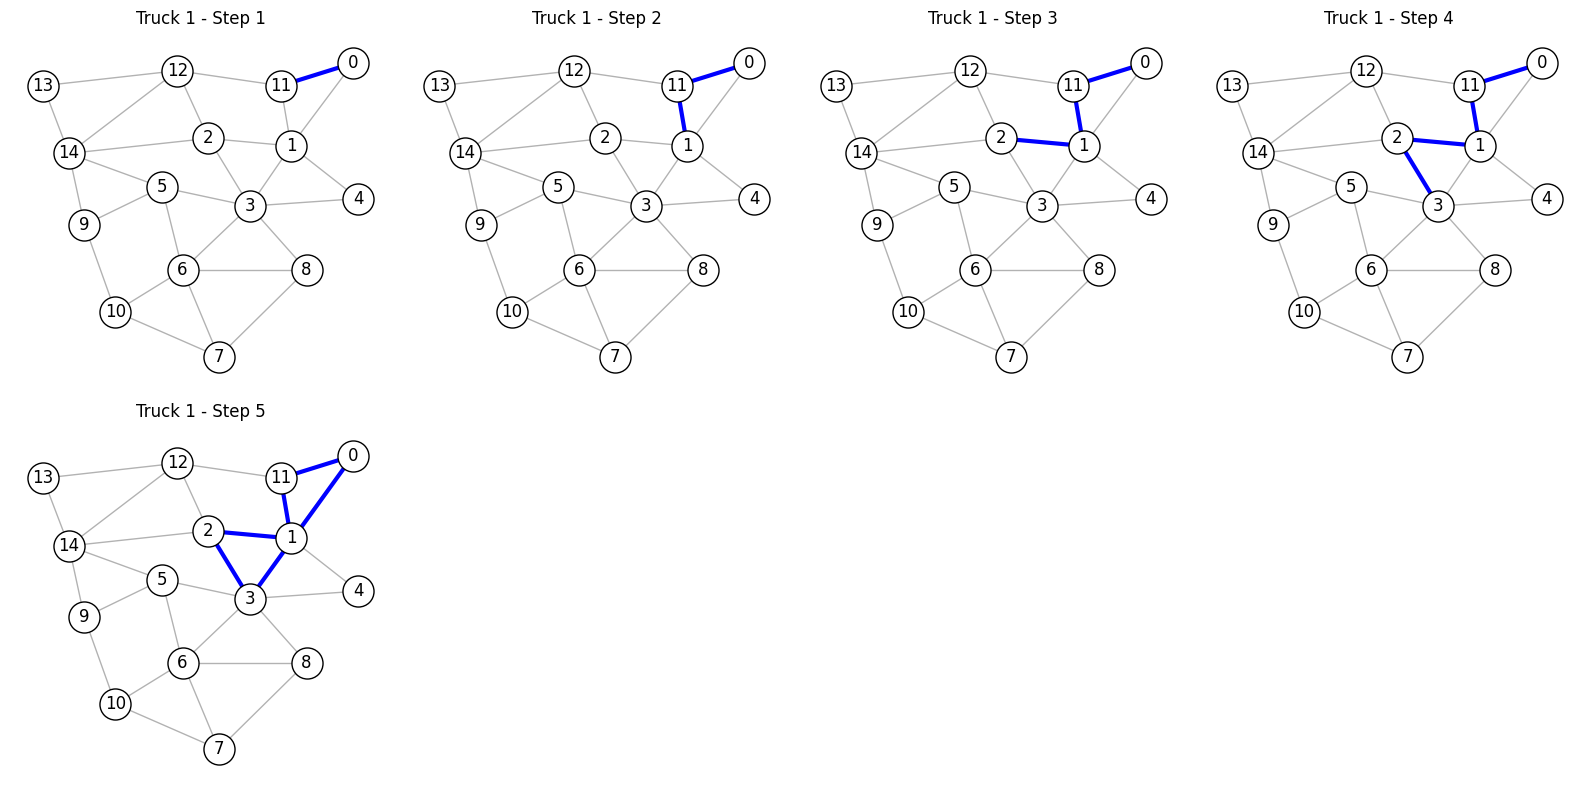


Truck ke-2:
Choose: 0 → 4
Choose: 4 → 6
Choose: 6 → 5
Choose: 5 → 14
Choose: 14 → 10


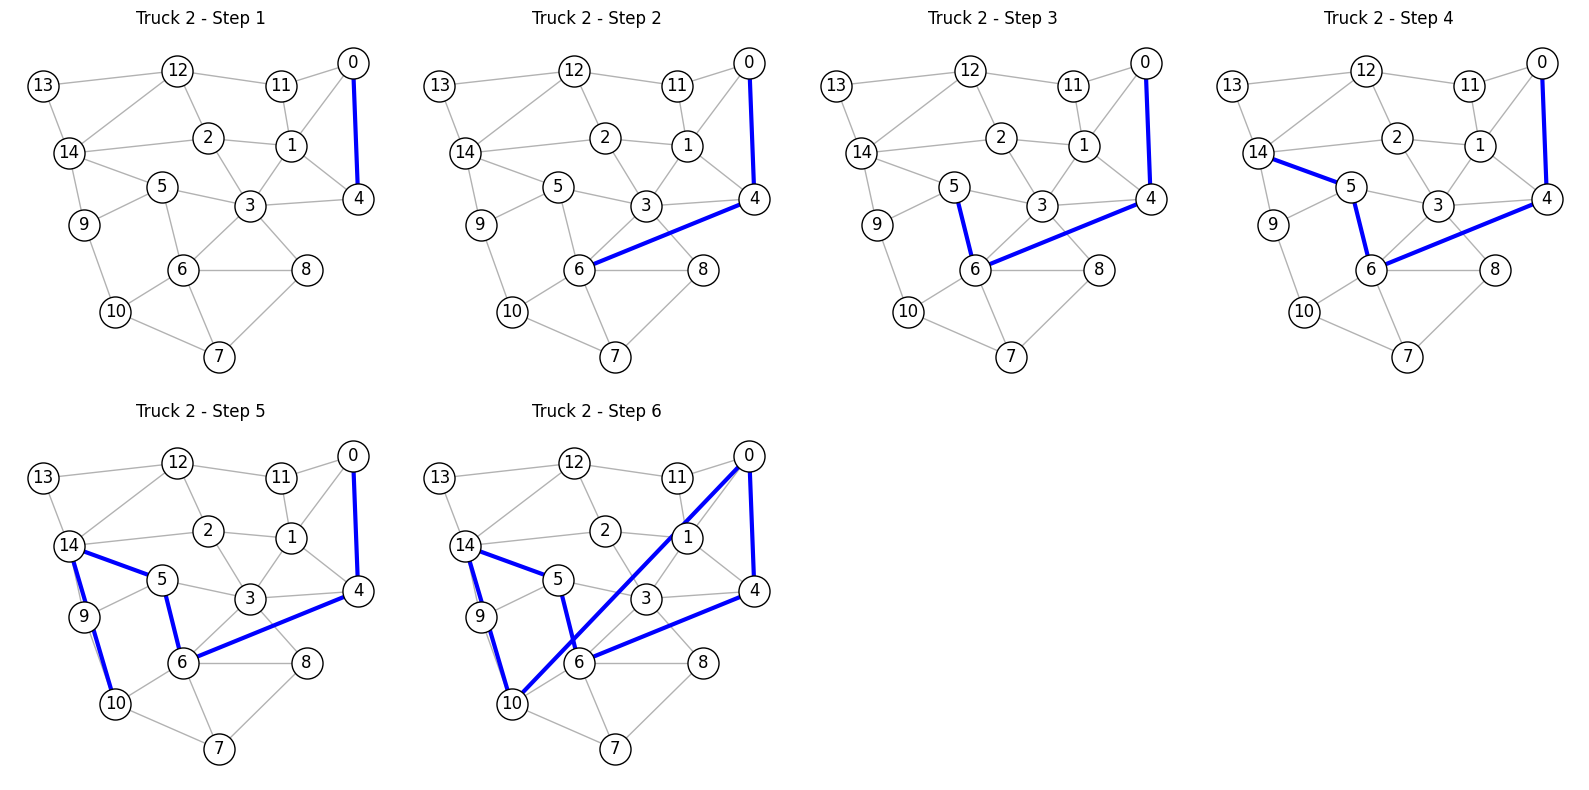


Truck ke-3:
Choose: 0 → 12
Choose: 12 → 9
Choose: 9 → 13


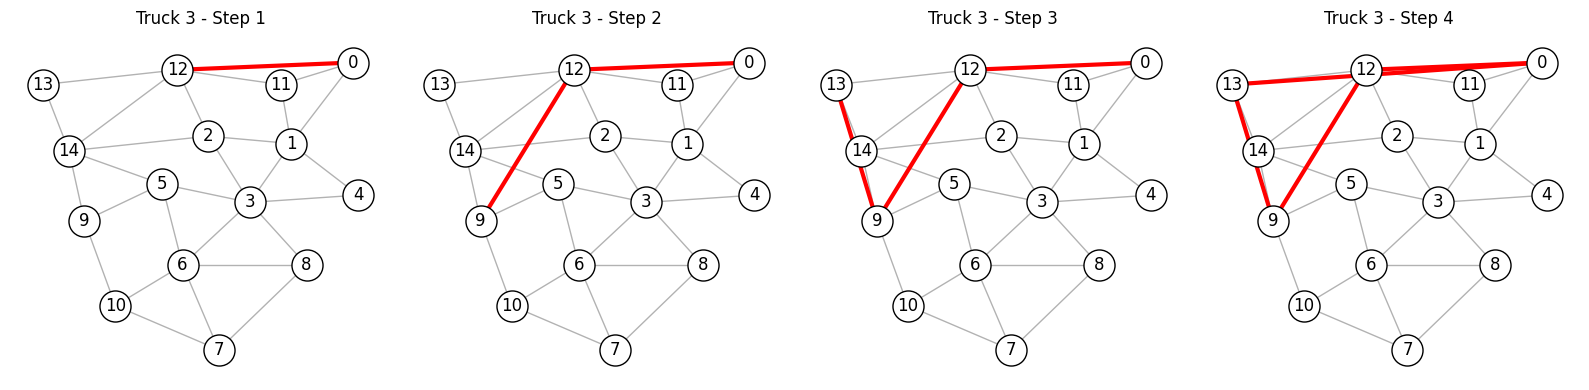


Truck ke-4:
Choose: 0 → 8
Choose: 8 → 7


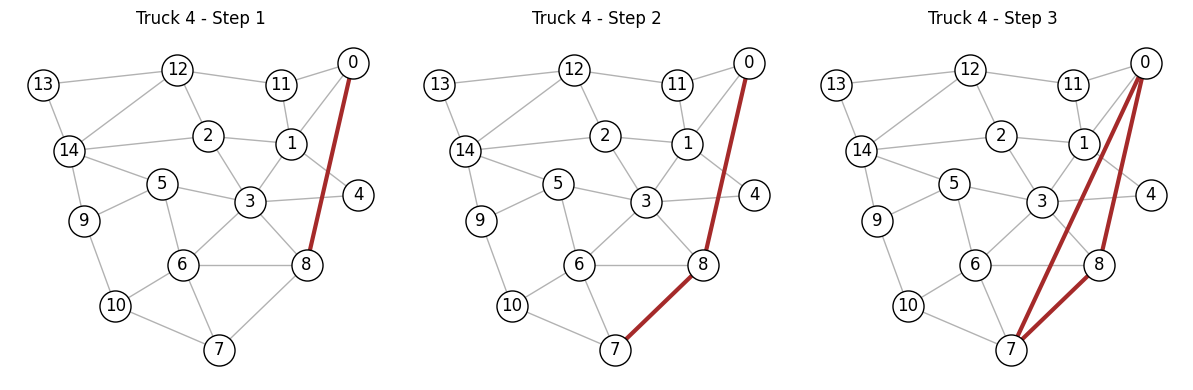

In [22]:
demands = [0,2,10,5,14,3,8,20,4,6,1,13,8,16,3]
capacity = 30
num_trucks = 5
depot = 0

truck_colors = ["red", "blue", "green", "orange", "purple", "brown"]

def plot_progress_subplots(G, pos, all_edges, truck_id):
    steps = len(all_edges)
    cols = 4
    rows = math.ceil(steps / cols)

    plt.figure(figsize=(cols * 4, rows * 4))
    angka = random.randint(0, 5)

    for i, route_edges in enumerate(all_edges):
        plt.subplot(rows, cols, i+1)
        nx.draw_networkx_nodes(G, pos, node_size=500, node_color='white', edgecolors='black')
        nx.draw_networkx_labels(G, pos)

        nx.draw_networkx_edges(G, pos, alpha=0.3)

        nx.draw_networkx_edges(G, pos, edgelist=route_edges, width=3, edge_color=truck_colors[angka])

        plt.title(f"Truck {truck_id} - Step {i+1}")
        plt.axis('off')

    plt.tight_layout()
    plt.show()

def nearest_neighbor_vrp_visual(distance_matrix, demands, capacity, num_trucks, G, pos, depot=0):
    n = len(distance_matrix)
    unvisited = set(range(1,n))
    routes = []
    loads = []
    dists = []

    for k in range(num_trucks):
        if not unvisited:
            break

        route = [depot]
        load = 0
        current = depot
        route_dist = 0

        route_edges = []
        snapshots = []

        print(f"\nTruck ke-{k+1}:")

        while True:
            candidates = [j for j in unvisited if demands[j] + load <= capacity]

            if not candidates:
                route.append(depot)
                route_edges.append((current, depot))
                snapshots.append(route_edges.copy())
                route_dist += distance_matrix[current][depot]
                break

            next_node = min(candidates, key=lambda j: distance_matrix[current][j])
            print(f"Choose: {current} → {next_node}")

            route.append(next_node)
            route_edges.append((current, next_node))
            snapshots.append(route_edges.copy())

            route_dist += distance_matrix[current][next_node]
            load += demands[next_node]
            unvisited.remove(next_node)
            current = next_node

            if not unvisited:
                route.append(depot)
                route_edges.append((current, depot))
                snapshots.append(route_edges.copy())
                route_dist += distance_matrix[current][depot]
                break

        plot_progress_subplots(G, pos, snapshots, k+1)

        routes.append(route)
        loads.append(load)
        dists.append(route_dist)

    return {
        "routes": routes,
        "loads": loads,
        "distances": dists,
        "total_distance": sum(dists),
        "unvisited": sorted(list(unvisited)),
        "infeasible": len(unvisited) > 0
    }

  
G = nx.Graph()
for i in range(n):
    G.add_node(i)

for (i,j,w) in edges:
    G.add_edge(i,j,weight=w)

pos = {
    0:  (3.9, 4.9),
    11: (3.2, 4.6),
    12: (2.2, 4.8),
    13: (0.9, 4.6),

    1:  (3.3, 3.8),
    2:  (2.5, 3.9),
    14: (1.15,3.7),
    4:  (3.95,3.1),

    3:  (2.9, 3.0),
    5:  (2.05,3.25),
    9:  (1.3, 2.75),

    6:  (2.25,2.15),
    8:  (3.45,2.15),

    10: (1.6, 1.6),
    7:  (2.6, 1.0)
}


sol = nearest_neighbor_vrp_visual(
    dist, demands, capacity, num_trucks,
    G, pos, depot=0
)


--- VRP Nearest Neighbor Solution ---

Truck 1: Route [0, 11, 1, 2, 3, 0] | Load = 30 | Distance = 40
Truck 2: Route [0, 4, 6, 5, 14, 10, 0] | Load = 29 | Distance = 80
Truck 3: Route [0, 12, 9, 13, 0] | Load = 30 | Distance = 73
Truck 4: Route [0, 8, 7, 0] | Load = 24 | Distance = 68

Total distance = 261


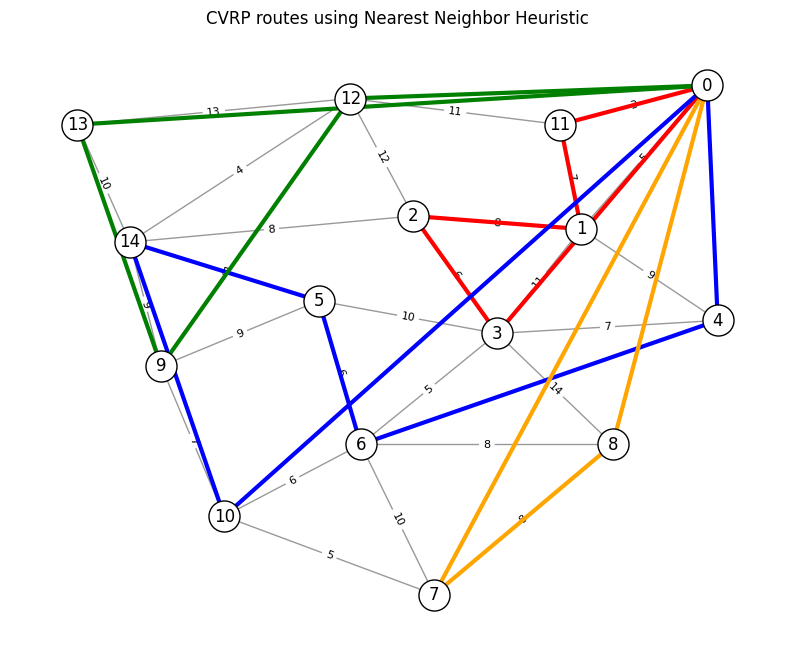

In [31]:
print("\n--- VRP Nearest Neighbor Solution ---\n")
for idx, route in enumerate(sol["routes"],1):
    print(f"Truck {idx}: Route {route} | Load = {sol['loads'][idx-1]} | Distance = {sol['distances'][idx-1]}")
print(f"\nTotal distance = {sol['total_distance']}")

plt.figure(figsize=(10,8))
nx.draw_networkx_nodes(G, pos, node_size=500, node_color='white', edgecolors='black')
nx.draw_networkx_labels(G, pos)
nx.draw_networkx_edges(G, pos, alpha=0.4)

edge_labels = {(i,j):w for (i,j,w) in edges}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=8)

colors = ["red","blue","green","orange"]
for idx, route in enumerate(sol["routes"]):
    edges_route = list(zip(route[:-1], route[1:]))
    nx.draw_networkx_edges(G, pos, edgelist=edges_route, width=3, edge_color=colors[idx%len(colors)])

plt.title("CVRP routes using Nearest Neighbor Heuristic")
plt.axis('off')
plt.show()


## Clarke Wright Algorithm in Classic Vehicle Routing Problem (CVRP)

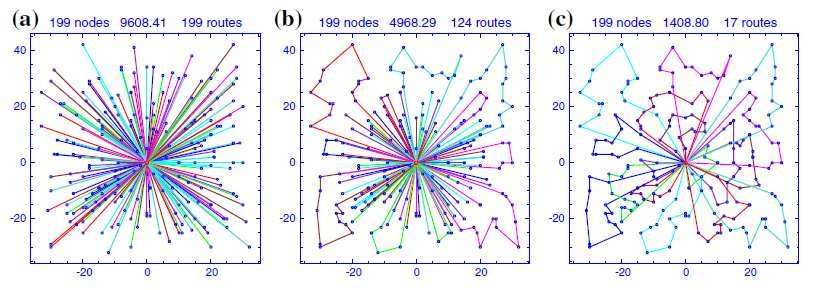

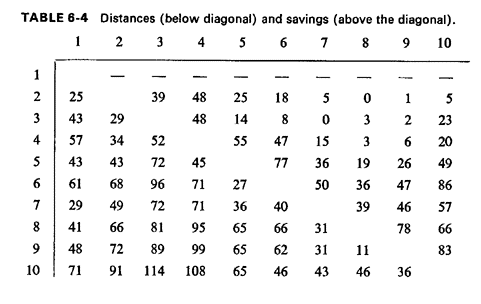

In [24]:
import numpy as np
import math
import networkx as nx
import matplotlib.pyplot as plt

edges = [
    (0,11,3), (0,1,5), (1,11,7),
    (1,2,8), (1,3,11), (1,4,9),
    (2,12,12), (2,14,8), (2,3,6),
    (3,5,10), (3,6,5), (3,8,14),
    (3,4,7), (5,14,5), (5,9,9),
    (5,6,6), (6,10,6),
    (6,7,10), (6,8,8), (7,10,5),
    (7,8,8), (8,3,14), (8,6,8),
    (8,7,8), (9,14,9), (9,5,9),
    (9,10,7), (10,6,6), (10,7,5),
    (10,9,7), (11,12,11), (11,1,7),
    (12,13,13), (12,14,4), (12,11,11),
    (12,2,12), (13,12,13), (13,14,10),
    (14,13,10), (14,12,4), (14,2,8),
    (14,5,5), (14,9,9)
]

demands = [0,2,10,5,14,3,8,20,4,6,1,13,8,16,3]
capacity = 30
depot = 0

n = 15
INF = 10**9

adj = [[INF]*n for _ in range(n)]
for i in range(n):
    adj[i][i] = 0

for (i,j,w) in edges:
    adj[i][j] = w
    adj[j][i] = w

dist = np.array(adj, dtype=float)
for k in range(n):
    for i in range(n):
        for j in range(n):
            newd = dist[i,k] + dist[k,j]
            if newd < dist[i,j]:
                dist[i,j] = newd

dist = np.rint(dist).astype(int)

df_dist = pd.DataFrame(dist, index=range(n), columns=range(n))

print("Distance Matrix:")
df_dist



Distance Matrix:


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14
0,0,5,13,16,14,23,21,31,29,27,27,3,14,27,18
1,5,0,8,11,9,21,16,26,24,25,22,7,18,26,16
2,13,8,0,6,13,13,11,21,19,17,17,15,12,18,8
3,16,11,6,0,7,10,5,15,13,18,11,18,18,24,14
4,14,9,13,7,0,17,12,22,20,25,18,16,25,31,21
5,23,21,13,10,17,0,6,16,14,9,12,20,9,15,5
6,21,16,11,5,12,6,0,10,8,13,6,23,15,21,11
7,31,26,21,15,22,16,10,0,8,12,5,33,25,31,21
8,29,24,19,13,20,14,8,8,0,20,13,31,23,29,19
9,27,25,17,18,25,9,13,12,20,0,7,24,13,19,9


In [25]:
def compute_savings_table(dist, depot=0):
    N = len(dist)
    rows = []

    for i in range(1, N):
        for j in range(i+1, N):
            Sij = dist[depot][i] + dist[depot][j] - dist[i][j]
            rows.append([i, j, dist[depot][i], dist[depot][j], dist[i][j], Sij])

    df = pd.DataFrame(rows, columns=[
        "i", "j",
        "D(0,i)", "D(0,j)", "D(i,j)",
        "Saving S(i,j)"
    ])

    df_sorted = df.sort_values(by="Saving S(i,j)", ascending=False)

    return df, df_sorted

df, df_sorted = compute_savings_table(dist, depot=0)

df

,i,j,"D(0,i)","D(0,j)","D(i,j)","Saving S(i,j)"
0,1,2,5,13,8,10
1,1,3,5,16,11,10
2,1,4,5,14,9,10
3,1,5,5,23,21,7
4,1,6,5,21,16,10
...,...,...,...,...,...,...
86,11,13,3,27,24,6
87,11,14,3,18,15,6
88,12,13,14,27,13,28
89,12,14,14,18,4,28


In [26]:
df_sorted

,i,j,"D(0,i)","D(0,j)","D(i,j)","Saving S(i,j)"
65,7,10,31,27,5,53
63,7,8,31,29,8,52
76,9,10,27,27,7,47
64,7,9,31,27,12,46
71,8,10,29,27,13,43
...,...,...,...,...,...,...
42,4,11,14,3,16,1
72,8,11,29,3,31,1
66,7,11,31,3,33,1
59,6,11,21,3,23,1


In [ ]:
pos = {
    0:  (3.9, 4.9),
    11: (3.2, 4.6),
    12: (2.2, 4.8),
    13: (0.9, 4.6),

    1:  (3.3, 3.8),
    2:  (2.5, 3.9),
    14: (1.15,3.7),
    4:  (3.95,3.1),

    3:  (2.9, 3.0),
    5:  (2.05,3.25),
    9:  (1.3, 2.75),

    6:  (2.25,2.15),
    8:  (3.45,2.15),

    10: (1.6, 1.6),
    7:  (2.6, 1.0)
}

G = nx.Graph()
for i in range(n):
    G.add_node(i)
for (i,j,w) in edges:
    G.add_edge(i,j,weight=w)

def clarke_wright(dist, demands, capacity, depot=0, max_trucks=4):
    N = len(dist)

    routes = {i:[depot, i, depot] for i in range(N) if i != depot}

    savings = []
    for i in range(1, N):
        for j in range(i+1, N):
            Sij = dist[depot][i] + dist[depot][j] - dist[i][j]
            savings.append((Sij, i, j))

    savings.sort(reverse=True)

    snapshots = []

    initial_edges = []
    for r in routes.values():
        initial_edges.extend(list(zip(r[:-1], r[1:])))
    snapshots.append(initial_edges)

    used_savings = []

    for S, i, j in savings:

        if len(routes) <= max_trucks:
            break

        route_i = None
        route_j = None
        for r in routes.values():
            if r[-2] == i:
                route_i = r
            if r[1] == j:
                route_j = r

        if route_i is None or route_j is None:
            continue
        if route_i == route_j:
            continue

        load_i = sum(demands[x] for x in route_i[1:-1])
        load_j = sum(demands[x] for x in route_j[1:-1])
        if load_i + load_j > capacity:
            continue

        new_route = route_i[:-1] + route_j[1:]

        key_i = [k for k,v in routes.items() if v==route_i][0]
        key_j = [k for k,v in routes.items() if v==route_j][0]
        del routes[key_i]
        del routes[key_j]

        routes[i] = new_route
        used_savings.append((S, i, j))   # <=== NEW

        edges_step = []
        for r in routes.values():
            edges_step.extend(list(zip(r[:-1], r[1:])))
        snapshots.append(edges_step)

    return list(routes.values()), snapshots, savings, used_savings


routes, progress, savings, used_savings = clarke_wright(dist, demands, capacity, depot)

def visualize_steps(G, pos, progress, color="red"):

    steps = len(progress)
    cols = 4
    rows = math.ceil(steps/cols)

    plt.figure(figsize=(cols*4, rows*4))

    for step, edges_step in enumerate(progress):
        plt.subplot(rows, cols, step+1)
        nx.draw_networkx_nodes(G, pos, node_size=500, node_color='white', edgecolors='black')
        nx.draw_networkx_labels(G, pos)
        nx.draw_networkx_edges(G, pos, alpha=0.3)
        nx.draw_networkx_edges(G, pos, edgelist=edges_step, edge_color=color, width=3)
        plt.title(f"Step {step+1}")
        plt.axis("off")

    plt.tight_layout()
    plt.show()


In [ ]:
def savings_table(savings, used_savings):
    df = pd.DataFrame(savings, columns=["Saving", "i", "j"])
    df["Used"] = "No"

    used_set = {(i,j,S) for (S,i,j) in used_savings}

    df["Used"] = df.apply(lambda row:
                          "Yes" if (row["i"], row["j"], row["Saving"]) in 
                          {(i,j,S) for (S,i,j) in used_savings}
                          else "No", axis=1)

    df = df.sort_values(by="Saving", ascending=False).reset_index(drop=True)
    return df

routes, progress, savings, used_savings = clarke_wright(dist, demands, capacity, depot)

df_saving = savings_table(savings, used_savings)

df_used = df_saving[df_saving["Used"] == "Yes"].sort_values(by="Saving", ascending=False)
df_used

,Saving,i,j,Used
0,53,7,10,Yes
6,42,6,8,Yes
8,41,5,9,Yes
13,36,9,14,Yes
22,32,3,7,Yes
27,28,12,13,Yes
41,23,4,6,Yes
49,23,2,5,Yes
69,10,1,4,Yes


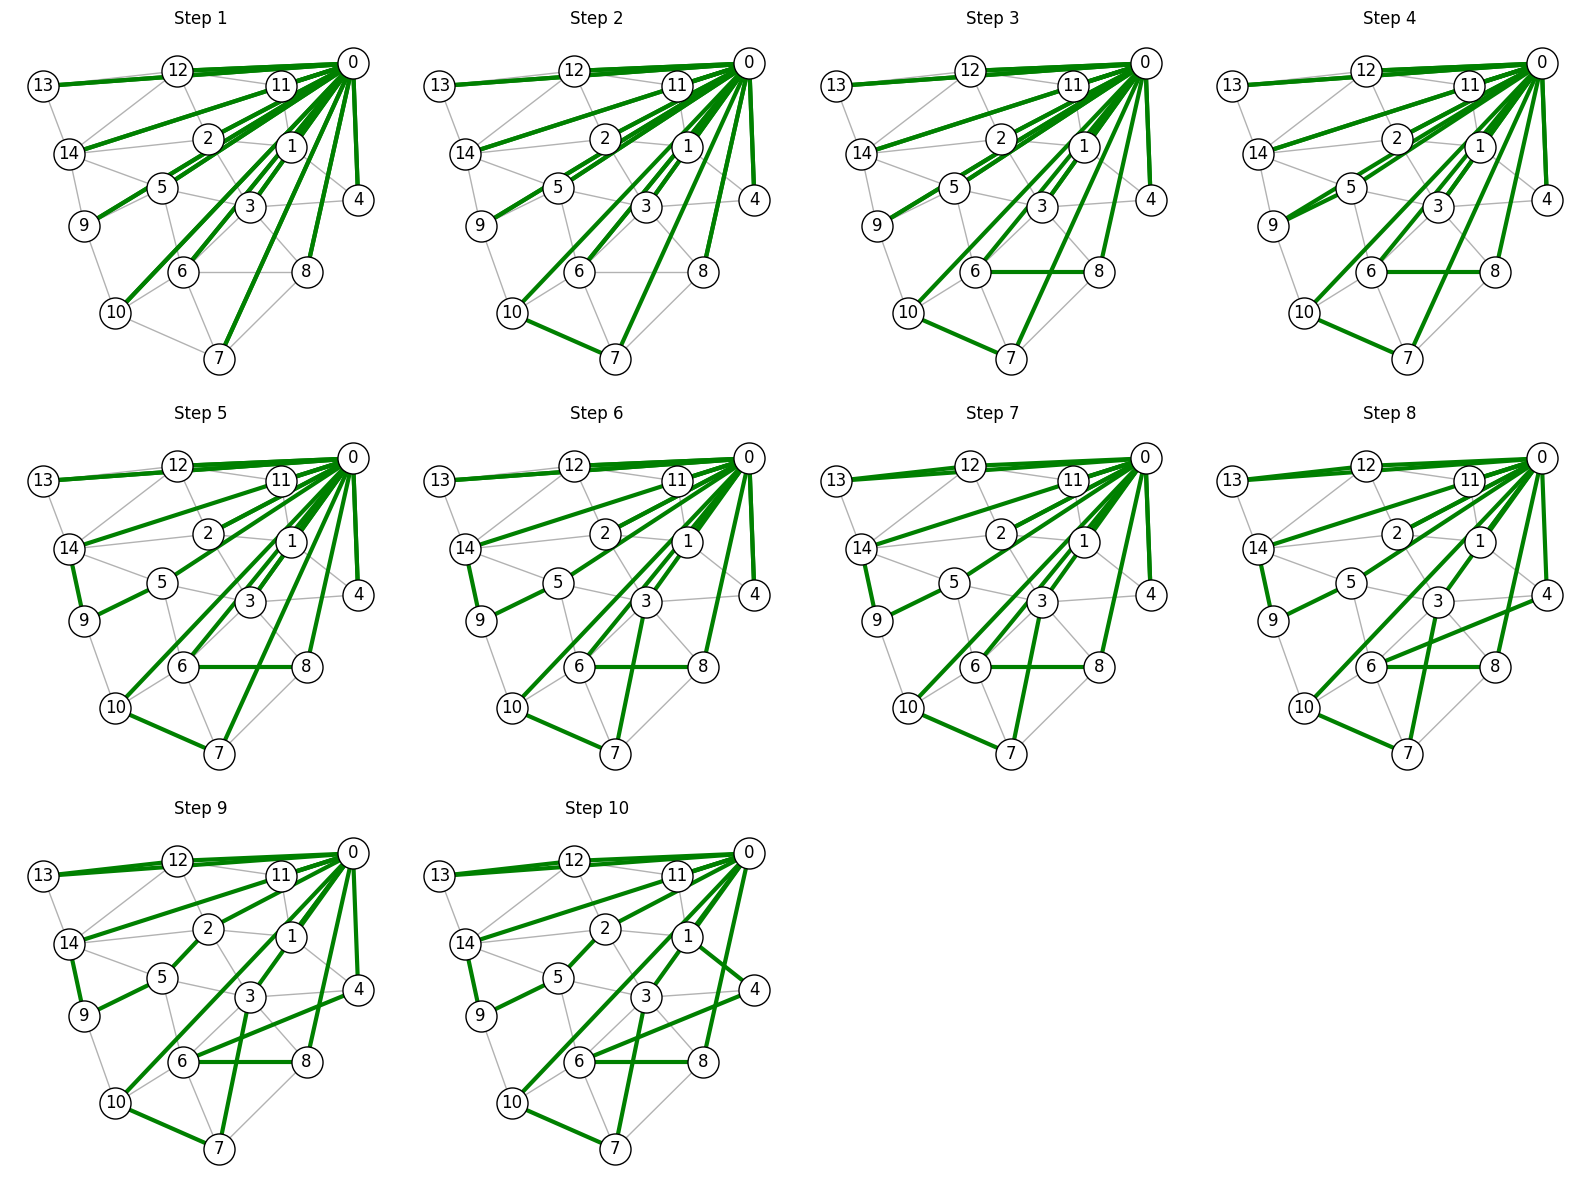

Final routes:
[0, 11, 0]
[0, 3, 7, 10, 0]
[0, 12, 13, 0]
[0, 2, 5, 9, 14, 0]
[0, 1, 4, 6, 8, 0]


In [29]:
visualize_steps(G, pos, progress, color="green")

print("Final routes:")
for r in routes:
    print(r)